In [1]:
from pathlib import Path
import os
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
TEST_SIZE = 0.2
SKEW_THRESHOLD = 0.75

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data/raw/train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess import (
    OUTLIER_GR_LIV_AREA,
    OUTLIER_PRICE,
    clean_and_engineer,
)

raw_path = Path("data/raw/train.csv")
df = pd.read_csv(raw_path)
print("Thư mục dự án:", PROJECT_ROOT)
print("Kích thước dữ liệu:", df.shape)

Thư mục dự án: d:\house_price_project
Kích thước dữ liệu: (1460, 81)


In [2]:
df.info()
print("Trùng lặp:", df.duplicated().sum())

miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("Tỷ lệ thiếu (%):")
print((miss / len(df) * 100).round(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Ghi chú dữ liệu và quyết định tiền xử lý

Bộ dữ liệu là Ames Housing, trong đó `SalePrice` là giá bán nhà và được biến đổi bằng `log1p` để giảm độ lệch. Hai dòng có `GrLivArea > 4000` nhưng `SalePrice < 300000` được xem là outlier không đại diện và được loại bỏ. `GarageYrBlt` được bỏ vì trùng lặp thông tin với năm xây dựng và có missing value. Các cột chất lượng được ánh xạ theo thứ tự `None < Po < Fa < TA < Gd < Ex`; các biến phân loại hiếm được gom qua `min_frequency=2` trong bước one-hot. Median `LotFrontage` theo `Neighborhood` chỉ được tính trên tập train sau khi chia dữ liệu, với median toàn train làm fallback.

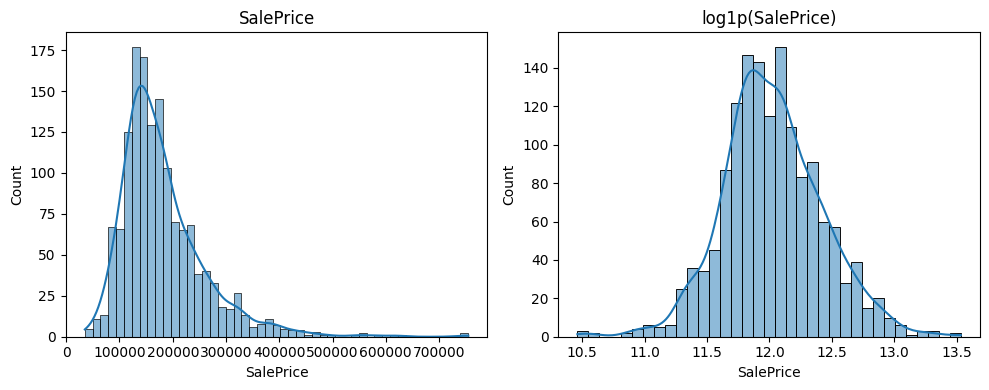

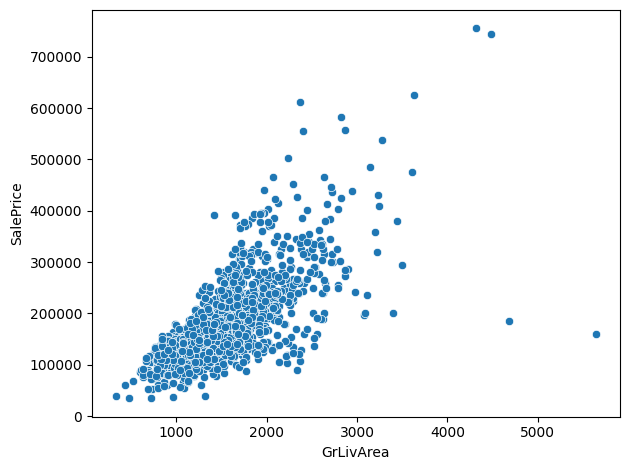

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["SalePrice"], kde=True, ax=ax[0])
ax[0].set_title("SalePrice")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=ax[1])
ax[1].set_title("log1p(SalePrice)")
plt.tight_layout()
plt.show()

sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.tight_layout()
plt.show()

In [4]:
outlier_mask = (
    (df["GrLivArea"] > OUTLIER_GR_LIV_AREA)
    & (df["SalePrice"] < OUTLIER_PRICE)
)
print("Outlier sẽ loại:", int(outlier_mask.sum()), "dòng")

Outlier sẽ loại: 2 dòng


In [5]:
df = clean_and_engineer(df)
print("Kích thước sau làm sạch và tạo đặc trưng:", df.shape)
print("Còn thiếu sau xử lý thủ công:")
print(df.isnull().sum()[lambda values: values > 0])

Kích thước sau làm sạch và tạo đặc trưng: (1458, 83)
Còn thiếu sau xử lý thủ công:
LotFrontage    259
Electrical       1
dtype: int64


In [6]:
engineered_columns = ["TotalSF", "HouseAge", "RemodAge", "TotalBath"]
print("Đặc trưng mới:", engineered_columns)
print("Kiểu MSSubClass:", df["MSSubClass"].dtype)
print("Còn thiếu trước pipeline:", int(df.drop(columns="SalePrice").isnull().sum().sum()))

Đặc trưng mới: ['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath']
Kiểu MSSubClass: object
Còn thiếu trước pipeline: 260


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

X = df.drop(columns="SalePrice")
y = np.log1p(df["SalePrice"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

group_medians = X_train.groupby("Neighborhood")["LotFrontage"].median()
global_median = X_train["LotFrontage"].median()
for frame in (X_train, X_test):
    frame["LotFrontage"] = (
        frame["LotFrontage"]
        .fillna(frame["Neighborhood"].map(group_medians))
        .fillna(global_median)
    )

y_train = y_train.rename("log_SalePrice")
y_test = y_test.rename("log_SalePrice")

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
skew = X_train[num_cols].skew()
skewed_cols = skew[skew.abs() > SKEW_THRESHOLD].index.tolist()
normal_cols = [column for column in num_cols if column not in skewed_cols]

skew_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("sc", StandardScaler()),
])
norm_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
])
cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(
        handle_unknown="ignore", min_frequency=2, sparse_output=False
    )),
])

preprocessor = ColumnTransformer(
    [
        ("skew", skew_pipe, skewed_cols),
        ("norm", norm_pipe, normal_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    verbose_feature_names_out=False,
)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print("Trước:", X_train.shape[1], "cột -> Sau:", X_train_p.shape[1], "cột")

Trước: 82 cột -> Sau: 265 cột


In [8]:
X_train_df = pd.DataFrame(X_train_p, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_p, columns=feature_names, index=X_test.index)

assert X_train_df.isnull().sum().sum() == 0
assert X_test_df.isnull().sum().sum() == 0
assert list(X_train_df.columns) == list(X_test_df.columns)
assert y_train.name == "log_SalePrice"
assert y_test.name == "log_SalePrice"
print(X_train_df.shape, X_test_df.shape, y_train.shape, y_test.shape)

(1166, 265) (292, 265) (1166,) (292,)


In [9]:
X_train_df.to_csv("data/processed/X_train.csv", index=False)
X_test_df.to_csv("data/processed/X_test.csv", index=False)
y_train.to_csv("data/processed/y_train.csv", index=False)
y_test.to_csv("data/processed/y_test.csv", index=False)
pd.Series(feature_names, name="feature").to_csv(
    "data/processed/feature_names.csv", index=False
)
joblib.dump(preprocessor, "models/preprocessor.pkl")
print("Đã lưu X_train, X_test, y_train, y_test, feature_names và preprocessor.")

Đã lưu X_train, X_test, y_train, y_test, feature_names và preprocessor.


In [10]:
print("Còn NaN:", X_train_df.isnull().sum().sum(), X_test_df.isnull().sum().sum())
print("Số dòng train/test:", X_train_df.shape[0], X_test_df.shape[0])
print("Số cột sau one-hot:", X_train_df.shape[1])
print("Cột train/test giống nhau:", list(X_train_df.columns) == list(X_test_df.columns))
print("Trung bình 5 cột đầu (phải gần 0):", X_train_df.iloc[:, :5].mean().round(2).tolist())
print("y_train (log) min/max:", y_train.min().round(2), y_train.max().round(2))

for output_path in [
    "data/processed/X_train.csv",
    "data/processed/X_test.csv",
    "data/processed/y_train.csv",
    "data/processed/y_test.csv",
    "data/processed/feature_names.csv",
    "models/preprocessor.pkl",
]:
    assert Path(output_path).exists(), output_path
print("Đã kiểm tra đủ file đầu ra.")

Còn NaN: 0 0
Số dòng train/test: 1166 292
Số cột sau one-hot: 265
Cột train/test giống nhau: True
Trung bình 5 cột đầu (phải gần 0): [-0.0, -0.0, 0.0, -0.0, -0.0]
y_train (log) min/max: 10.46 13.53
Đã kiểm tra đủ file đầu ra.
